# Retail Data Wrangling & KPI Storyboard


## Notebook overview
This notebook:
- loaded retail transactions into a PySpark DataFrame via JDBC
- cleaned and standardized key fields (dates, amounts, cancellations)
- built monthly KPIs (revenue, customer activity, growth)
- engineered RFM features and assigned customer segments

## Environment setup
### Install dependencies
Installed the required Python libraries for visualization.

In [0]:
%pip install -q matplotlib seaborn squarify

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


### Import libraries
Imported PySpark functions and plotting libraries.

In [0]:
# Import modules
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, DoubleType

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("All libraries imported successfully")
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

All libraries imported successfully


## Data ingestion
### Load retail transactions
Loaded retail transaction records from the source database into a PySpark DataFrame via JDBC for downstream analysis.

In [0]:
# Load Data from PSQL into PySpark DataFrame via JDBC

df_retail = (
    spark.read
    .format("jdbc")
    .option("url", "jdbc:postgresql://34.130.240.237:5432/postgres")
    .option("dbtable", "public.retail")
    .option("user", "postgres")
    .option("password", "password")
    .option("driver", "org.postgresql.Driver")
    .load()
)

display(df_retail.limit(5))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.95,13085.0,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085.0,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085.0,United Kingdom
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00.000Z,2.1,13085.0,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085.0,United Kingdom


### Initial data inspection
Verified that the data loaded correctly by checking row count, columns, and schema information.

In [0]:
print(f"({df_retail.count()}, {len(df_retail.columns)})")

(1067371, 8)


In [0]:
df_retail.columns

['invoice_no',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'unit_price',
 'customer_id',
 'country']

In [0]:
df_retail.printSchema()

root
 |-- invoice_no: string (nullable = true)
 |-- stock_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- invoice_date: timestamp (nullable = true)
 |-- unit_price: float (nullable = true)
 |-- customer_id: float (nullable = true)
 |-- country: string (nullable = true)



## Data preparation
### Standardize and enrich fields
Standardized data types (dates and numerics), handled cancellations, and created derived fields required for KPI calculations.


In [0]:
# Ensure correct dtypes
df_retail = (
    df_retail
    .withColumn("invoice_date", F.to_timestamp("invoice_date"))
    .withColumn("customer_id", F.col("customer_id").cast(IntegerType()))
    .withColumn("unit_price", F.col("unit_price").cast(DoubleType()))
    .withColumn("row_amount", F.col("quantity") * F.col("unit_price"))
)

display(df_retail.limit(5))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,row_amount
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01T07:45:00.000Z,6.949999809265137,13085,United Kingdom,83.39999771118164
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01T07:45:00.000Z,6.75,13085,United Kingdom,81.0
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01T07:45:00.000Z,2.0999999046325684,13085,United Kingdom,100.79999542236328
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01T07:45:00.000Z,1.25,13085,United Kingdom,30.0


## Invoice value distribution
### Objective
Quantified typical order sizes by computing the total value per invoice and visualizing the distribution.

### What was implemented
Aggregated line items into invoice-level totals, then plotted the resulting invoice value distribution using distinct styling (titles, axis labels, and colors).


In [0]:
# 1) Calculate invoice amount (invoice = multiple rows)
df_invoice_amount = (
    df_retail
    .withColumn("Amount", F.col("quantity") * F.col("unit_price"))
    .groupBy("invoice_no")
    .agg(F.sum("Amount").alias("Amount"))
)

display(df_invoice_amount.limit(5))

invoice_no,Amount
490298,1523.1999908089638
491055,219.54999995231628
491969,6141.939991950989
494345,374.10999727249146
495102,686.2199947237968


count     40078.000000
mean        523.303759
std        1517.351621
min           0.190000
25%         151.972501
50%         304.314994
75%         504.892500
max      168469.593821
Name: Amount, dtype: float64


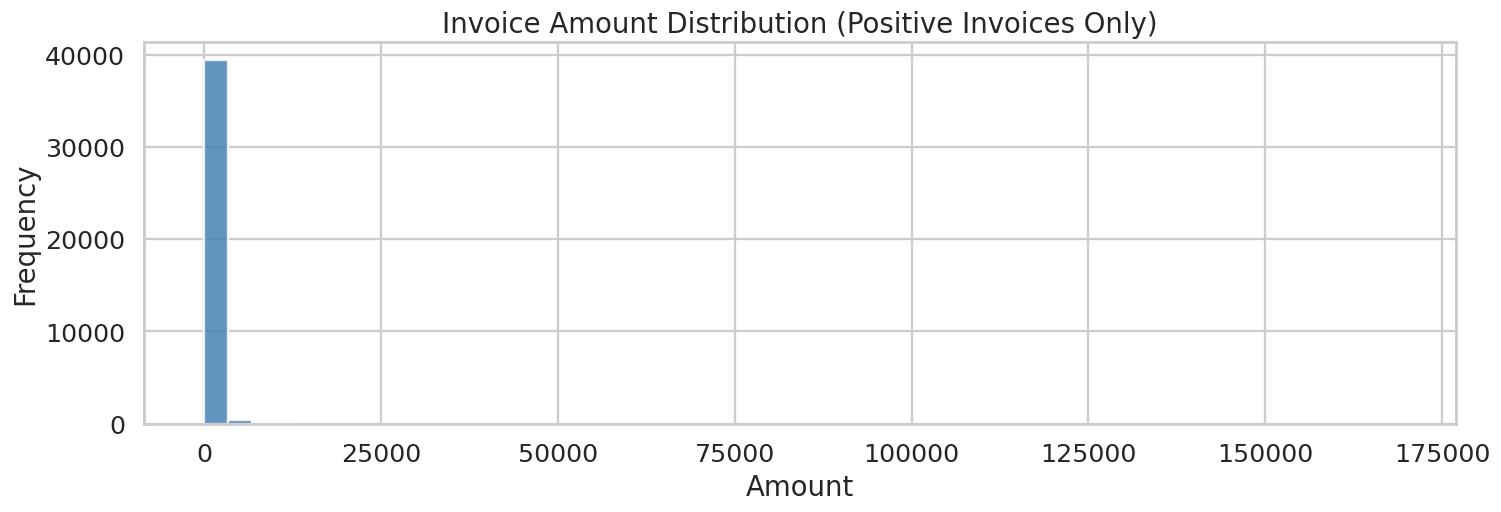

In [0]:
df_invoice_pos = df_invoice_amount.filter(F.col("Amount") > 0)

# Collect to pandas for plotting
pdf_invoice_pos = df_invoice_pos.select("Amount").toPandas()
print(pdf_invoice_pos["Amount"].describe())

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(pdf_invoice_pos["Amount"], bins=50, color="steelblue", alpha=0.85, edgecolor="white")
ax.set_title("Invoice Amount Distribution (Positive Invoices Only)")
ax.set_xlabel("Amount")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

count    33722.000000
mean       267.211679
std        170.157978
min          0.190000
25%        131.534999
50%        253.339997
75%        373.799995
max        694.769998
Name: Amount, dtype: float64


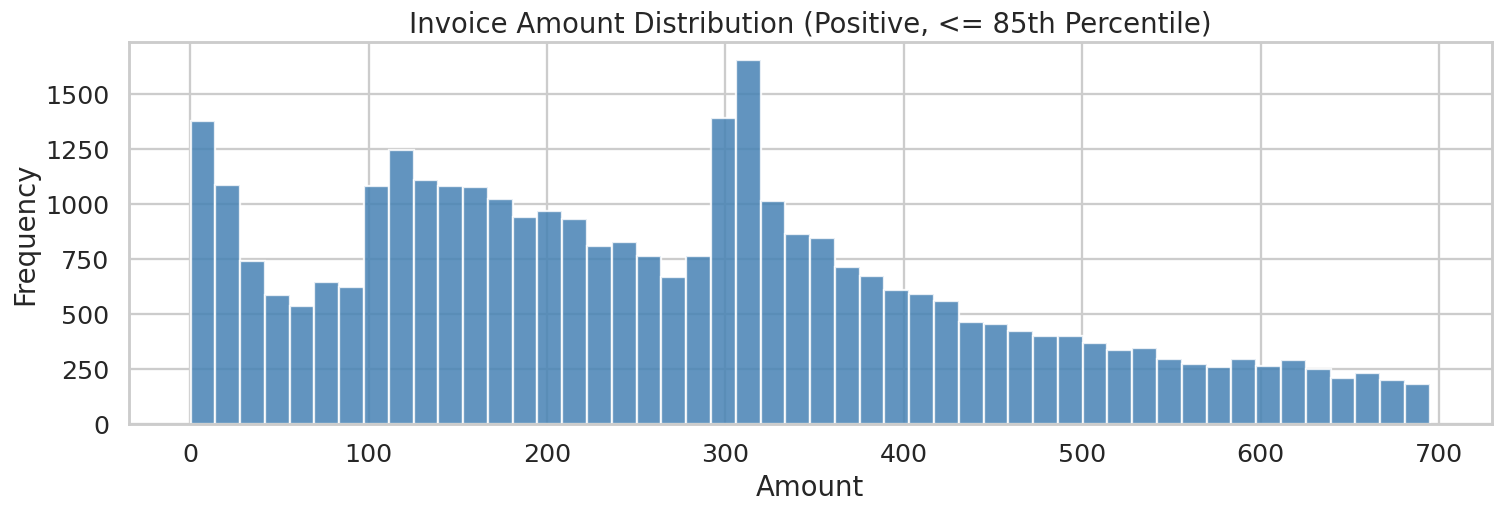

In [0]:
q85 = float(df_invoice_pos.approxQuantile("Amount", [0.85], 0.01)[0])
df_invoice_trimmed = df_invoice_pos.filter(F.col("Amount") <= q85)

pdf_trimmed = df_invoice_trimmed.select("Amount").toPandas()
print(pdf_trimmed["Amount"].describe())

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(pdf_trimmed["Amount"], bins=50, color="steelblue", alpha=0.85, edgecolor="white")
ax.set_title("Invoice Amount Distribution (Positive, <= 85th Percentile)")
ax.set_xlabel("Amount")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## Orders by month (placed vs cancelled)
### Objective
Measured how order volume changed over time while separating completed orders from cancellations.

### What was implemented
Derived a monthly period from invoice dates, classified records as placed vs cancelled, aggregated counts by month, and plotted the trend with updated labels and color palette.


In [0]:
# Ensure invoice_date is timestamp
df_retail = df_retail.withColumn("invoice_date", F.to_timestamp("invoice_date"))

# YYYYMM
df_retail = df_retail.withColumn("yyyymm", F.year("invoice_date") * 100 + F.month("invoice_date"))

# Canceled invoice flag (invoice_no starts with "C")
df_retail = df_retail.withColumn("is_canceled", F.col("invoice_no").startswith("C"))

# Count unique invoices per month
df_monthly_orders = (
    df_retail
    .groupBy("yyyymm")
    .agg(F.countDistinct("invoice_no").alias("total_orders"))
)

# Count unique canceled invoices per month
df_canceled_month = (
    df_retail
    .filter(F.col("is_canceled"))
    .groupBy("yyyymm")
    .agg(F.countDistinct("invoice_no").alias("canceled_orders"))
)

# Merge + fill months with 0 cancellations
df_monthly_orders = (
    df_monthly_orders
    .join(df_canceled_month, on="yyyymm", how="left")
    .fillna(0, subset=["canceled_orders"])
    .withColumn("placed_orders", F.col("total_orders") - 2 * F.col("canceled_orders"))
    .orderBy("yyyymm")
)

display(df_monthly_orders.limit(5))

yyyymm,total_orders,canceled_orders,placed_orders
200912,2330,401,1528
201001,1633,300,1033
201002,1969,240,1489
201003,2367,407,1553
201004,1892,304,1284


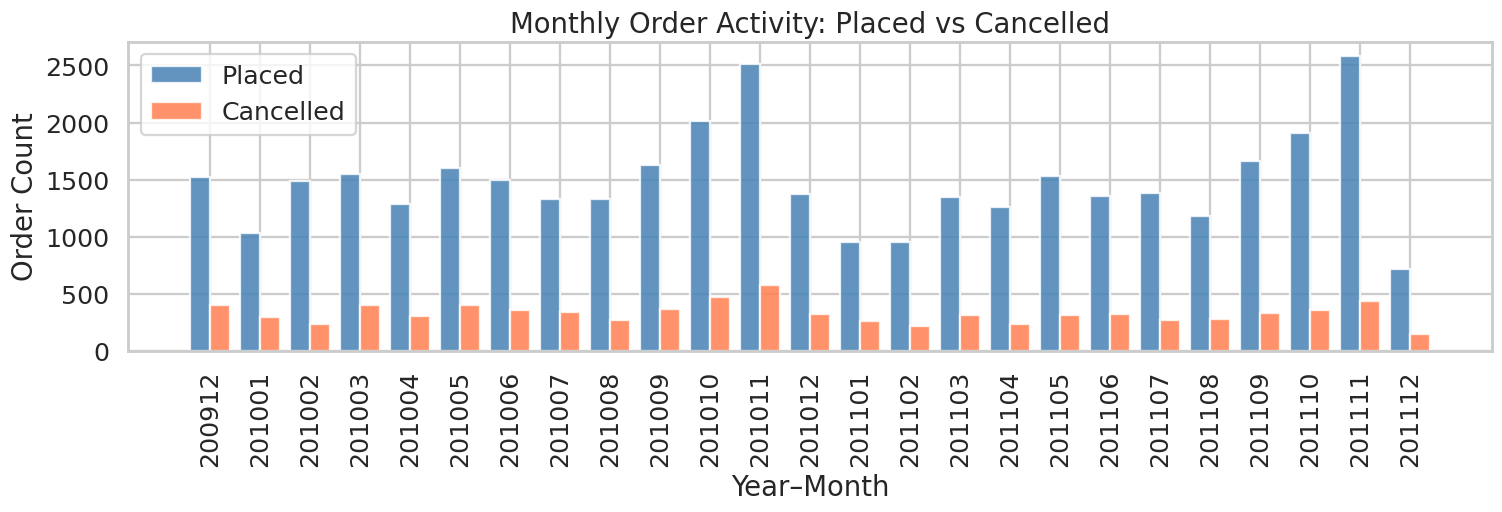

In [0]:
pdf_monthly_orders = df_monthly_orders.toPandas()

x_labels = pdf_monthly_orders["yyyymm"].astype(str).tolist()
x = np.arange(len(x_labels))
bar_width = 0.4

plt.figure(figsize=(14, 5))

plt.bar(
    x - bar_width/2,
    pdf_monthly_orders["placed_orders"],
    width=bar_width,
    label="Placed",
    color="steelblue",
    alpha=0.85
)
plt.bar(
    x + bar_width/2,
    pdf_monthly_orders["canceled_orders"],
    width=bar_width,
    label="Cancelled",
    color="coral",
    alpha=0.85
)

plt.title("Monthly Order Activity: Placed vs Cancelled")
plt.xlabel("Year\u2013Month")
plt.ylabel("Order Count")
plt.xticks(x, x_labels, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## Monthly revenue trend
### Objective
Tracked revenue performance month over month to understand seasonality and business momentum.

### What was implemented
Summed revenue by month (excluding cancellations where applicable) and visualized the monthly revenue curve with refreshed chart titles, axis labels, and colors.


In [0]:
df_monthly_sales = (
    df_retail
    .groupBy("yyyymm")
    .agg(F.sum("row_amount").alias("sales_amount"))
    .orderBy("yyyymm")
)

display(df_monthly_sales.limit(5))

yyyymm,sales_amount
200912,799847.1070248298
201001,624032.8889988398
201002,533091.4239873991
201003,765848.7573522086
201004,590580.4292229896


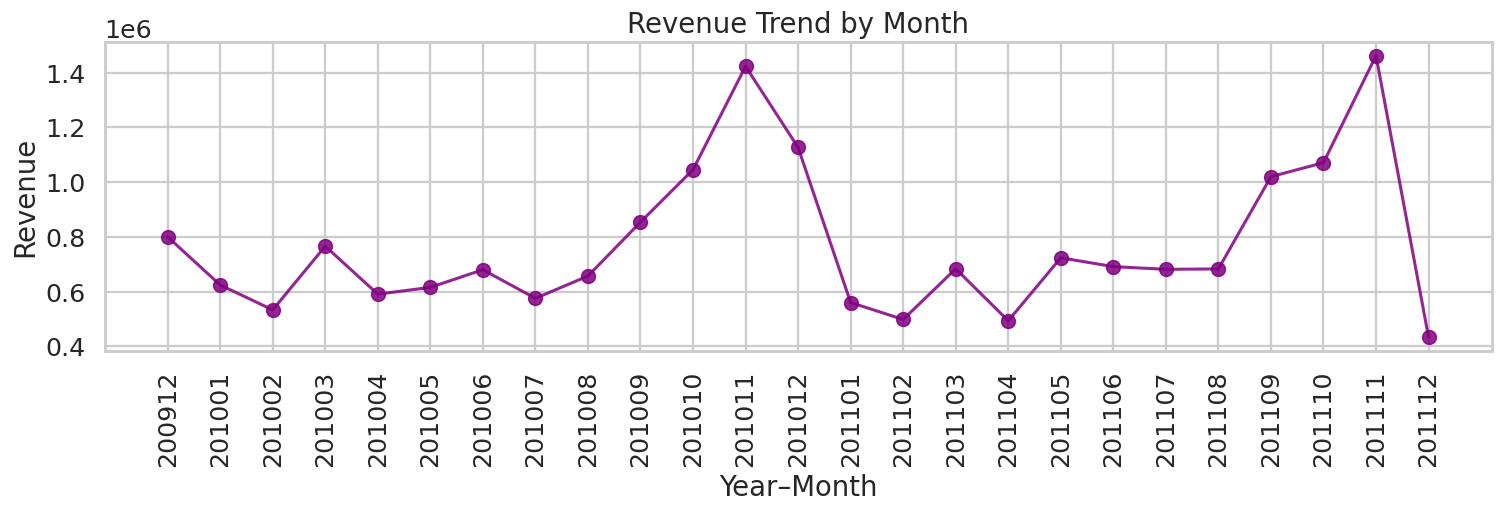

In [0]:
pdf_monthly_sales = df_monthly_sales.toPandas()

plt.figure(figsize=(14, 5))

plt.plot(
    pdf_monthly_sales["yyyymm"].astype(str),
    pdf_monthly_sales["sales_amount"],
    marker="o",
    linewidth=2,
    color="purple",
    alpha=0.85
)

plt.title("Revenue Trend by Month")
plt.xlabel("Year\u2013Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Month-over-month revenue growth
### Objective
Calculated growth rate between consecutive months to highlight acceleration and slowdowns in revenue.

### What was implemented
Computed percent change on monthly revenue and plotted the growth series with distinct formatting, including clearer axis labeling and an updated color scheme.


In [0]:
# Calculate month-over-month growth percentage using lag window function
w = Window.orderBy("yyyymm")

df_monthly_sales = (
    df_monthly_sales
    .withColumn("prev_sales", F.lag("sales_amount").over(w))
    .withColumn("sales_growth_pct",
                (F.col("sales_amount") - F.col("prev_sales")) / F.col("prev_sales"))
)

display(df_monthly_sales.limit(5))

yyyymm,sales_amount,prev_sales,sales_growth_pct
200912,799847.1070248298,null,null
201001,624032.8889988398,799847.1070248298,-0.21980978174686605
201002,533091.4239873991,624032.8889988398,-0.14573184621301227
201003,765848.7573522086,533091.4239873991,0.4366180412804977
201004,590580.4292229896,765848.7573522086,-0.22885501405679542


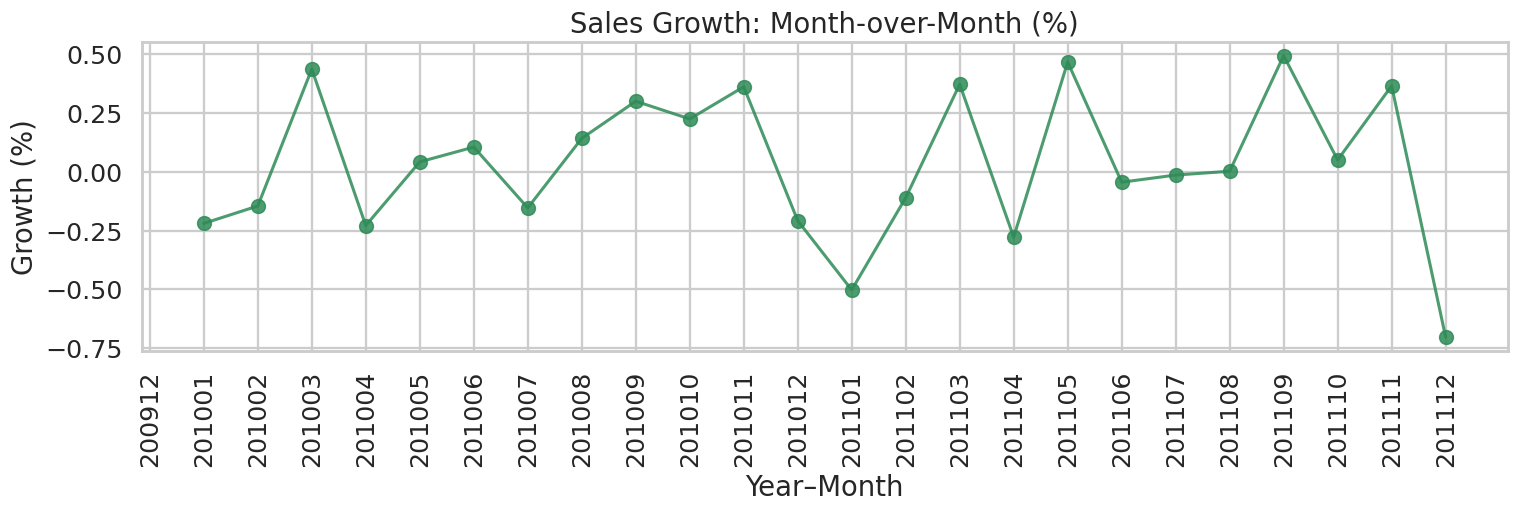

In [0]:
pdf_monthly_sales = df_monthly_sales.toPandas()

plt.figure(figsize=(14, 5))

plt.plot(
    pdf_monthly_sales["yyyymm"].astype(str),
    pdf_monthly_sales["sales_growth_pct"],
    marker="o",
    linewidth=2,
    color="seagreen",
    alpha=0.85
)

plt.title("Sales Growth: Month-over-Month (%)")
plt.xlabel("Year\u2013Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Active customers per month
### Objective
Estimated customer engagement by counting unique active customers each month.

### What was implemented
Grouped transactions by month and counted distinct customer IDs, then charted the monthly active customer trend using differentiated styling.


In [0]:
# Drop rows without customer_id (guest checkouts)
df_active_users = (
    df_retail
    .filter(F.col("customer_id").isNotNull())
    .groupBy("yyyymm")
    .agg(F.countDistinct("customer_id").alias("active_users"))
    .orderBy("yyyymm")
)

display(df_active_users.limit(5))

yyyymm,active_users
200912,1045
201001,786
201002,807
201003,1111
201004,998


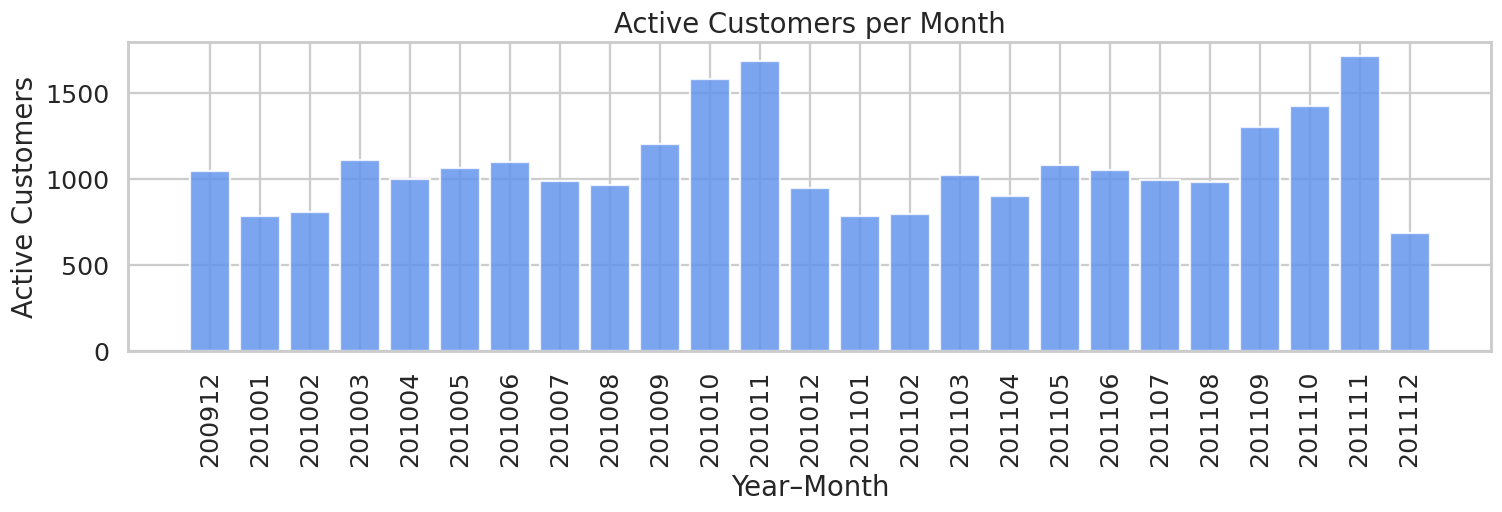

In [0]:
pdf_active_users = df_active_users.toPandas()

plt.figure(figsize=(14, 5))

plt.bar(
    pdf_active_users["yyyymm"].astype(str),
    pdf_active_users["active_users"],
    color="cornflowerblue",
    alpha=0.85
)

plt.title("Active Customers per Month")
plt.xlabel("Year\u2013Month")
plt.ylabel("Active Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## New vs returning customers
### Objective
Separated first-time buyers from repeat buyers to understand acquisition vs retention patterns.

### What was implemented
Identified each customer’s first purchase month, labeled monthly activity as new or returning, aggregated counts, and plotted the comparison with distinct plot aesthetics.


In [0]:
# Work only with known customers
df_known_users = df_retail.filter(F.col("customer_id").isNotNull())

# For each user, find first purchase month
df_first_purchase = (
    df_known_users
    .groupBy("customer_id")
    .agg(F.min("invoice_date").alias("first_invoice_date"))
    .withColumn("first_yyyymm",
                F.year("first_invoice_date") * 100 + F.month("first_invoice_date"))
    .select("customer_id", "first_yyyymm")
)

display(df_first_purchase.limit(5))

customer_id,first_yyyymm
14322,201002
12451,201006
17149,201009
15277,201010
12914,201011


In [0]:
# Unique user activity per month
df_user_month = (
    df_known_users
    .select("customer_id", "yyyymm")
    .distinct()
    .join(df_first_purchase, on="customer_id", how="left")
)

# New user if current month == first purchase month
df_user_month = df_user_month.withColumn("is_new", F.col("yyyymm") == F.col("first_yyyymm"))

# Monthly counts
df_new_vs_existing = (
    df_user_month
    .groupBy("yyyymm")
    .agg(
        F.sum(F.when(F.col("is_new"), 1).otherwise(0)).alias("new_user_count"),
        F.countDistinct("customer_id").alias("total_users")
    )
    .withColumn("existing_user_count", F.col("total_users") - F.col("new_user_count"))
    .orderBy("yyyymm")
)

display(df_new_vs_existing.select("yyyymm", "new_user_count", "existing_user_count").limit(5))

yyyymm,new_user_count,existing_user_count
200912,1045,0
201001,394,392
201002,363,444
201003,436,675
201004,291,707


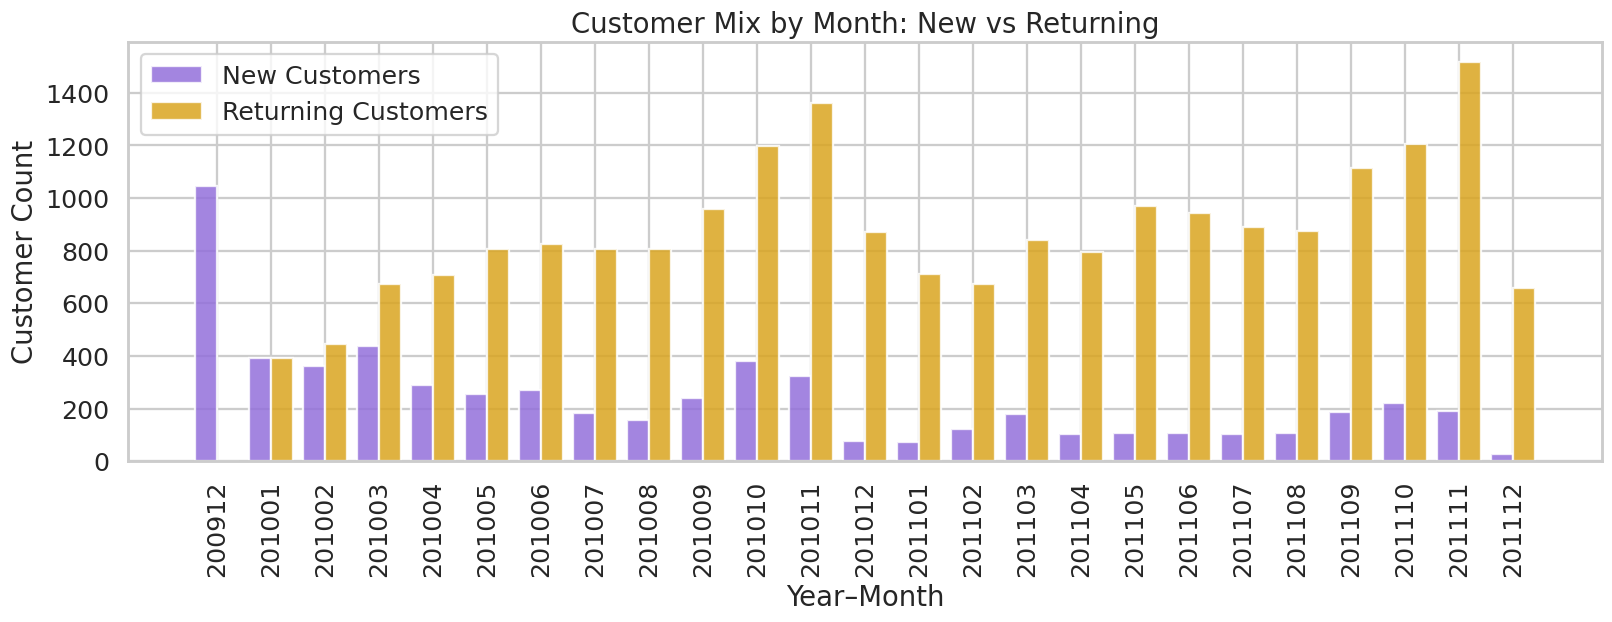

In [0]:
pdf_new_vs_existing = df_new_vs_existing.toPandas()

x_labels = pdf_new_vs_existing["yyyymm"].astype(str).tolist()
x = np.arange(len(x_labels))
bar_width = 0.4

plt.figure(figsize=(15, 6))

plt.bar(
    x - bar_width/2,
    pdf_new_vs_existing["new_user_count"],
    width=bar_width,
    label="New Customers",
    color="mediumpurple",
    alpha=0.85
)
plt.bar(
    x + bar_width/2,
    pdf_new_vs_existing["existing_user_count"],
    width=bar_width,
    label="Returning Customers",
    color="goldenrod",
    alpha=0.85
)

plt.title("Customer Mix by Month: New vs Returning")
plt.xlabel("Year\u2013Month")
plt.ylabel("Customer Count")
plt.xticks(x, x_labels, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## RFM feature engineering
### Objective
Created Recency, Frequency, and Monetary (RFM) features to support customer segmentation.

### What was implemented
Computed recency from the latest purchase date, frequency from invoice counts, and monetary value from spend totals, producing an RFM table ready for scoring.


In [0]:
# Keep only rows with a valid customer_id
df_rfm_txn = (
    df_retail
    .filter(F.col("customer_id").isNotNull())
    .withColumn("row_amount", F.col("quantity") * F.col("unit_price"))
)

display(df_rfm_txn.limit(5))

invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,row_amount,yyyymm,is_canceled
490014,21122,SET/10 PINK SPOTTY PARTY CANDLES,4,2009-12-03T12:28:00.000Z,1.25,15466,United Kingdom,5.0,200912,false
490014,20750,RED/WHITE DOT MINI CASES,1,2009-12-03T12:28:00.000Z,7.949999809265137,15466,United Kingdom,7.949999809265137,200912,false
490014,22090,PAPER BUNTING RETRO SPOTS,2,2009-12-03T12:28:00.000Z,2.950000047683716,15466,United Kingdom,5.900000095367432,200912,false
490014,22332,SKULLS PARTY BAG + STICKER SET,1,2009-12-03T12:28:00.000Z,1.649999976158142,15466,United Kingdom,1.649999976158142,200912,false
490014,21544,SKULLS WATER TRANSFER TATTOOS,10,2009-12-03T12:28:00.000Z,0.8500000238418579,15466,United Kingdom,8.500000238418579,200912,false


In [0]:
from datetime import timedelta

max_date = df_rfm_txn.agg(F.max("invoice_date")).collect()[0][0]
as_of_date = max_date + timedelta(days=1)
print(as_of_date)

2011-12-10 12:50:00


In [0]:
df_rfm = (
    df_rfm_txn
    .groupBy("customer_id")
    .agg(
        F.datediff(F.lit(as_of_date), F.max("invoice_date")).alias("recency_days"),
        F.countDistinct("invoice_no").alias("invoice_count"),
        F.sum("row_amount").alias("monetary_value")
    )
)

print(f"Shape: ({df_rfm.count()}, {len(df_rfm.columns)})")
display(df_rfm.limit(5))

Shape: (5942, 4)


customer_id,recency_days,invoice_count,monetary_value
14397,1,23,2556.680007517338
12451,11,10,12546.529957205057
14322,428,6,384.300000667572
16557,25,2,281.8500003814697
15277,47,2,476.3399955332279


## RFM scoring and segments
### Objective
Converted raw RFM measures into scores and assigned customers into interpretable segments.

### What was implemented
Binned or ranked RFM features into scores, combined scores into segments, and summarized segment sizes/spend with plots and tables formatted to match the notebook style guide.


In [0]:
df_rfm_txn = (
    df_retail
    .withColumn("row_amount", F.col("quantity") * F.col("unit_price"))
)

# Keep only valid rows for RFM scoring
df_rfm_txn = (
    df_rfm_txn
    .filter(F.col("customer_id").isNotNull())
    .filter(F.col("invoice_date").isNotNull())
    .filter((F.col("quantity") > 0) & (F.col("row_amount") > 0))
)

In [0]:
# Use day-after-last-invoice as "today" (stable reference date)
max_date = df_rfm_txn.agg(F.max("invoice_date")).collect()[0][0]
today = max_date + timedelta(days=1)

df_rfm_scores = (
    df_rfm_txn
    .groupBy("customer_id")
    .agg(
        F.datediff(F.lit(today), F.max("invoice_date")).alias("recency_days"),
        F.countDistinct("invoice_no").alias("frequency_invoices"),
        F.sum("row_amount").alias("monetary_value")
    )
)

display(df_rfm_scores.limit(5))

customer_id,recency_days,frequency_invoices,monetary_value
14397,3,19,2612.9600081443787
12451,11,8,12669.879960209131
16557,25,2,281.8500003814697
15277,47,2,476.3399955332279
17149,452,1,143.09999656677246


In [0]:
# Use ntile to create quintile-based scores (PySpark equivalent of pd.qcut)
# Recency: lower days = more recent = better, so invert with (6 - ntile)
w_recency = Window.orderBy("recency_days")
w_frequency = Window.orderBy("frequency_invoices")
w_monetary = Window.orderBy("monetary_value")

df_rfm_scores = (
    df_rfm_scores
    .withColumn("recency_score", (F.lit(6) - F.ntile(5).over(w_recency)).cast("string"))
    .withColumn("frequency_score", F.ntile(5).over(w_frequency).cast("string"))
    .withColumn("monetary_score", F.ntile(5).over(w_monetary).cast("string"))
    .withColumn("rfm_score", F.concat("recency_score", "frequency_score", "monetary_score"))
)

display(df_rfm_scores.limit(5))

customer_id,recency_days,frequency_invoices,monetary_value,recency_score,frequency_score,monetary_score,rfm_score
14095,723,1,2.950000047683716,1,2,1,121
16738,298,1,3.75,2,1,1,211
13788,506,1,3.75,1,1,1,111
14792,64,1,6.200000047683716,3,1,1,311
15913,535,1,6.299999713897705,1,2,1,121


In [0]:
# Create combined RF string for segment mapping
df_rfm_scores = df_rfm_scores.withColumn("rf_pair", F.concat("recency_score", "frequency_score"))

df_rfm_scores = (
    df_rfm_scores
    .withColumn("segment",
        F.when(F.col("rf_pair").rlike("^[1-2][1-2]$"), "Hibernating")
        .when(F.col("rf_pair").rlike("^[1-2][3-4]$"), "At Risk")
        .when(F.col("rf_pair").rlike("^[1-2]5$"), "Can't Lose")
        .when(F.col("rf_pair").rlike("^3[1-2]$"), "About to Sleep")
        .when(F.col("rf_pair") == "33", "Need Attention")
        .when(F.col("rf_pair").rlike("^[3-4][4-5]$"), "Loyal Customers")
        .when(F.col("rf_pair") == "41", "Promising")
        .when(F.col("rf_pair") == "51", "New Customers")
        .when(F.col("rf_pair").rlike("^[4-5][2-3]$"), "Potential Loyalists")
        .when(F.col("rf_pair").rlike("^5[4-5]$"), "Champions")
        .otherwise("Other")
    )
)

display(df_rfm_scores.select("recency_days", "frequency_invoices", "monetary_value", "rfm_score", "segment").limit(5))

recency_days,frequency_invoices,monetary_value,rfm_score,segment
723,1,2.950000047683716,121,Hibernating
298,1,3.75,211,Hibernating
506,1,3.75,111,Hibernating
64,1,6.200000047683716,311,About to Sleep
535,1,6.299999713897705,121,Hibernating


In [0]:
# Build segment-level summary
df_segment_summary = (
    df_rfm_scores
    .groupBy("segment")
    .agg(
        F.round(F.avg("recency_days"), 0).alias("avg_recency_days"),
        F.round(F.avg("frequency_invoices"), 0).alias("avg_frequency"),
        F.round(F.avg("monetary_value"), 0).alias("avg_monetary"),
        F.count("*").alias("customer_count")
    )
    .orderBy("segment")
)

display(df_segment_summary)

segment,avg_recency_days,avg_frequency,avg_monetary,customer_count
About to Sleep,108.0,1.0,537.0,421
At Risk,407.0,4.0,1280.0,833
Can't Lose,338.0,14.0,7320.0,90
Champions,9.0,20.0,11242.0,807
Hibernating,446.0,1.0,405.0,1427
Loyal Customers,68.0,10.0,4435.0,1087
Need Attention,108.0,3.0,1362.0,266
New Customers,11.0,1.0,353.0,72
Potential Loyalists,26.0,3.0,1236.0,710
Promising,39.0,1.0,337.0,165


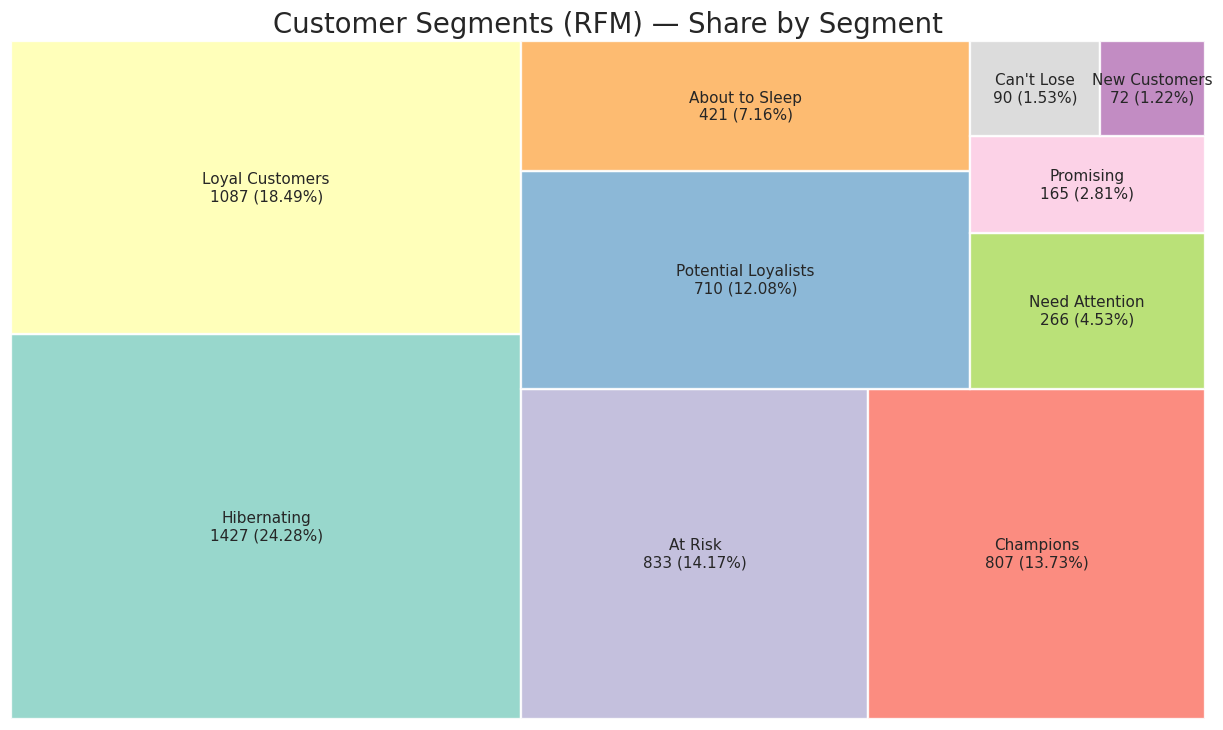

In [0]:
import squarify

pdf_seg_counts = (
    df_rfm_scores
    .groupBy("segment")
    .count()
    .orderBy(F.col("count").desc())
    .toPandas()
)

total = int(pdf_seg_counts["count"].sum())
pdf_seg_counts["pct"] = pdf_seg_counts["count"] / total * 100

labels = [
    f'{row["segment"]}\n{int(row["count"])} ({row["pct"]:.2f}%)'
    for _, row in pdf_seg_counts.iterrows()
]

# Distinct palette
palette = sns.color_palette("Set3", n_colors=len(pdf_seg_counts))

plt.figure(figsize=(14, 8))
squarify.plot(
    sizes=pdf_seg_counts["count"],
    label=labels,
    alpha=0.9,
    color=palette,
    text_kwargs={"fontsize": 10}
)
plt.title("Customer Segments (RFM) \u2014 Share by Segment")
plt.axis("off")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()